In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://flu-warning-serial-brilliant.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [6]:
# ─────────────────────────────────────────────
# 분석 환경 세팅 — 패키지 / 한글 폰트 / 출력 옵션
# ─────────────────────────────────────────────

# [1] 패키지 설치 + 그래프 인라인 출력
!pip install missingno plotly -q
!apt-get -y install fonts-nanum -q
%matplotlib inline

# [2] 임포트
import os
import platform
import warnings

# 라이브러리는 (폰트 처리 부분빼고) 각 학습에 맞게 수정
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 폰트 처리
import plotly.io as pio

# [3] 경고 숨기기 + 난수 고정(결과 재현용)
warnings.filterwarnings("ignore")
np.random.seed(42)

# [4] 한글 폰트 확보
#     리눅스(코랩)는 폰트 캐시가 갱신 안 되는 경우가 많아,
#     나눔고딕을 목록 맨 앞에 직접 끼워넣어 우선 적용시킴
if platform.system() == "Linux":
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    font_family = "DejaVu Sans"  # 폰트가 없을 때 대비
    if os.path.exists(nanum_path):
        fm.fontManager.ttflist.insert(0, fm.FontEntry(fname=nanum_path, name="NanumGothic_Force"))
        font_family = "NanumGothic_Force"
else:
    # 맥 / 윈도우 로컬 환경
    font_family = "AppleGothic" if platform.system() == "Darwin" else "Malgun Gothic"

# [5] 스타일 → 개별 설정 순서로 적용 (seaborn이 rcParams를 덮어쓰기 때문)
sns.set_theme(style="whitegrid", font=font_family)
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# [6] 코랩 전용 출력 옵션 (없는 환경이면 조용히 통과)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    pio.renderers.default = "colab"
except ImportError:
    pass

print(f"준비 완료! [적용 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용 폰트: NanumGothic_Force]


In [4]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


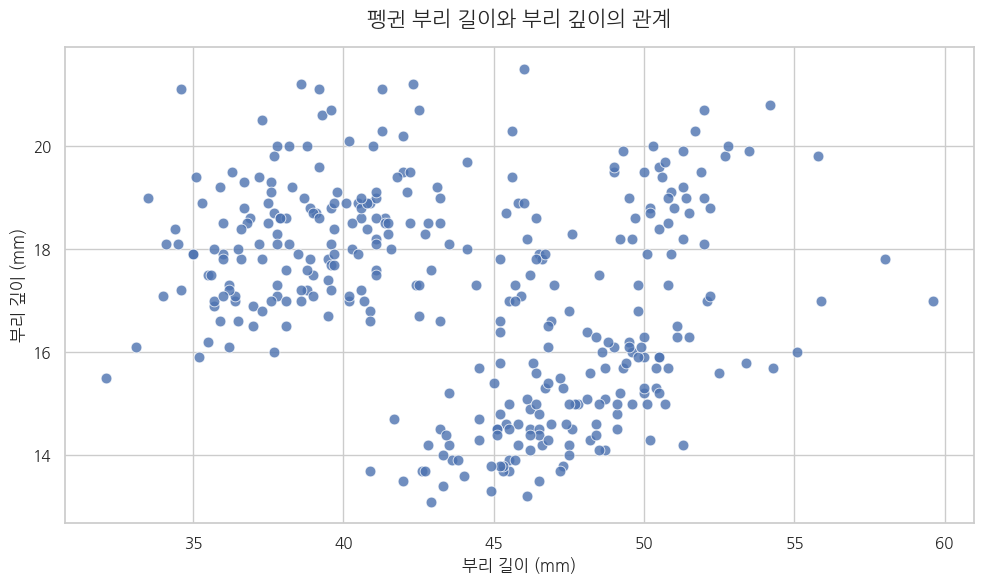

In [7]:
# ─────────────────────────────────────────────
# 문제1: Q1 · 부리 길이 vs 부리 깊이 산점도
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    s=60,          # 점 크기
    alpha=0.8      # 투명도 (겹친 점 구분용)
)

plt.title('펭귄 부리 길이와 부리 깊이의 관계', fontsize=15, pad=15)
plt.xlabel('부리 길이 (mm)', fontsize=12)
plt.ylabel('부리 깊이 (mm)', fontsize=12)

plt.tight_layout()
plt.show()

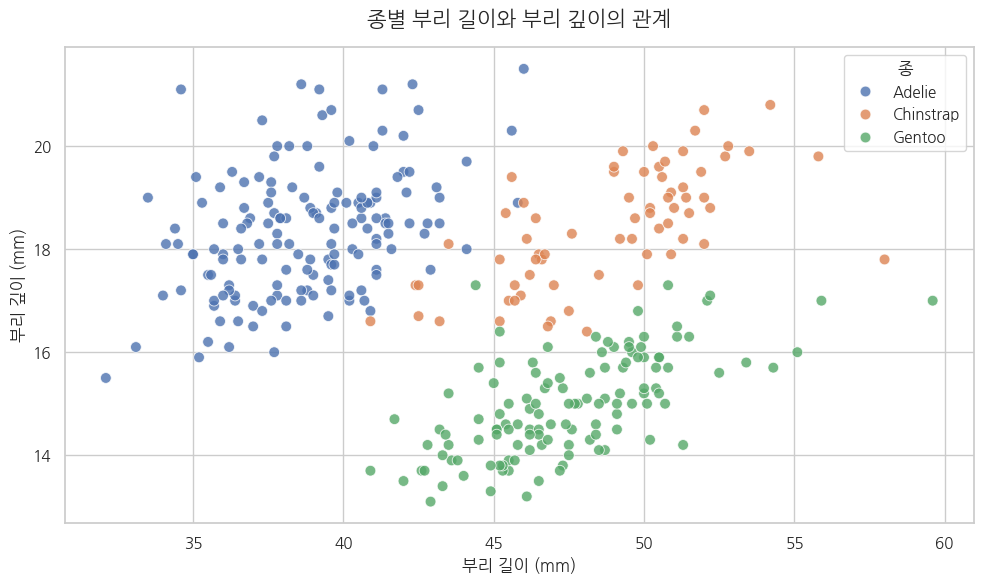

In [9]:
# ─────────────────────────────────────────────
# 문제 1: Q2 · 종별 색상 구분 산점도
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',   # 종별로 색상 구분
    s=60,
    alpha=0.8
)

plt.title('종별 부리 길이와 부리 깊이의 관계', fontsize=15, pad=15)
plt.xlabel('부리 길이 (mm)', fontsize=12)
plt.ylabel('부리 깊이 (mm)', fontsize=12)
plt.legend(title='종')

plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────
# 문제 1: Q3 · 전체 vs 종별 상관계수 비교
# ─────────────────────────────────────────────

# 전체 데이터 상관계수
corr_all = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
print("[전체] 부리 길이 vs 부리 깊이 상관계수:")
display(corr_all)

# 종별 상관계수
corr_by_species = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print("[종별] 부리 길이 vs 부리 깊이 상관계수:")
display(corr_by_species)

# ─────────────────────────────────────────────
# 문제 1: Q3 · 종별 상관계수만 깔끔하게 뽑기
# ─────────────────────────────────────────────

corr_summary = penguins.groupby('species').apply(
    lambda g: g['bill_length_mm'].corr(g['bill_depth_mm'])
)
print("종별 상관계수 (요약):")
display(corr_summary)

print(f"\n전체 상관계수: {corr_all.iloc[0, 1]:.3f}")

[전체] 부리 길이 vs 부리 깊이 상관계수:


,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.235053
bill_depth_mm,-0.235053,1.000000


[종별] 부리 길이 vs 부리 깊이 상관계수:


bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000

종별 상관계수 (요약):


,0
species,
Adelie,0.391492
Chinstrap,0.653536
Gentoo,0.643384



전체 상관계수: -0.235


## 문제 1 정리 — 결과를 말로 설명해 보기

**① Q1의 산점도 방향과 Q3 전체 상관계수의 부호 일치 여부**

Q1(이미지 2)의 산점도는 점들이 전체적으로 왼쪽 위에서 오른쪽 아래로 흩어진 모양, 즉 부리 길이가 길어질수록 깊이가 얕아지는 **음의 방향**으로 보입니다. Q3에서 계산한 전체 상관계수도 **-0.235로 음수**이니, 눈으로 본 방향과 숫자가 정확히 일치합니다.

**② Q3 종별 상관계수, 전체와 부호가 같은가**

전혀 다릅니다. Adelie(0.391), Chinstrap(0.654), Gentoo(0.643) — 세 종 모두 **양수**입니다. 전체는 음수인데 종별로는 셋 다 양수, 부호가 완전히 뒤집혔습니다.

**③ 왜 이런 착시가 생기는가**

Q2(이미지 1)를 보면 이유가 바로 보입니다. 세 종은 각각 **부리 길이 축에서 서로 다른 구간에 자리 잡고** 있습니다.

- Adelie는 왼쪽(35 ~ 46mm 근처)에 몰려 있으면서 깊이는 상대적으로 깊고(17 ~ 21mm)
- Gentoo는 오른쪽(45 ~ 60mm 근처)에 몰려 있으면서 깊이는 상대적으로 얕음(13 ~ 17mm)
- Chinstrap은 그 중간 ~ 오른쪽 구간에 있으면서 깊이는 Adelie와 비슷하게 깊은 편

즉 **종이라는 변수가 부리 길이와도 관련이 있고, 부리 깊이와도 관련이 있는 숨은 공변량(confounder)** 역할을 합니다. 종이 다르면 "부리의 기본 체급"이 통째로 다르게 세팅되는 셈이죠. 그래서:

- **종을 무시하면**: 서로 다른 세 개의 "구름"(종)이 대각선 방향으로 나란히 늘어서 있는 걸 하나의 뭉치로 착각하게 되고, 그 결과 전체를 관통하는 추세선이 실제로는 존재하지 않는 음의 관계처럼 보입니다.
- **종을 고려하면**: 각 구름 안에서는 부리가 길수록 깊이도 함께 커지는, 생물학적으로 자연스러운 양의 관계가 드러납니다.

이건 세 그룹 사이의 "위치 차이(종별 평균 차이)"가 만들어낸 착시일 뿐, 실제 개체 수준의 관계는 그 반대라는 뜻입니다.

**④ '종' 정보가 없었다면 어떤 잘못된 결론을 냈을까**

만약 species 컬럼 자체가 없었다면, 전체 상관계수 -0.235만 보고 "펭귄은 부리가 길수록 깊이가 얕아지는 경향이 있다"는 결론을 내렸을 겁니다. 이는 데이터 전체에서는 통계적으로 맞는 숫자지만, 개체 수준·종 수준의 실제 생물학적 관계와는 **정반대 방향**이라는 점에서 완전히 잘못된 해석입니다.

---

**정리하자면**: 종을 무시하면 "부리 길이와 깊이는 음의 관계"이고, 종을 고려하면 "부리 길이와 깊이는 (각 종 안에서) 양의 관계"입니다. 이게 심슨의 역설이고, 핵심은 **숨은 그룹 변수(confounder)가 두 변수 모두와 관련되어 있을 때 전체 통계량만으로는 진짜 관계를 놓칠 수 있다**는 것입니다.

결측치 제거 전: 344 행
결측치 제거 후: 342 행


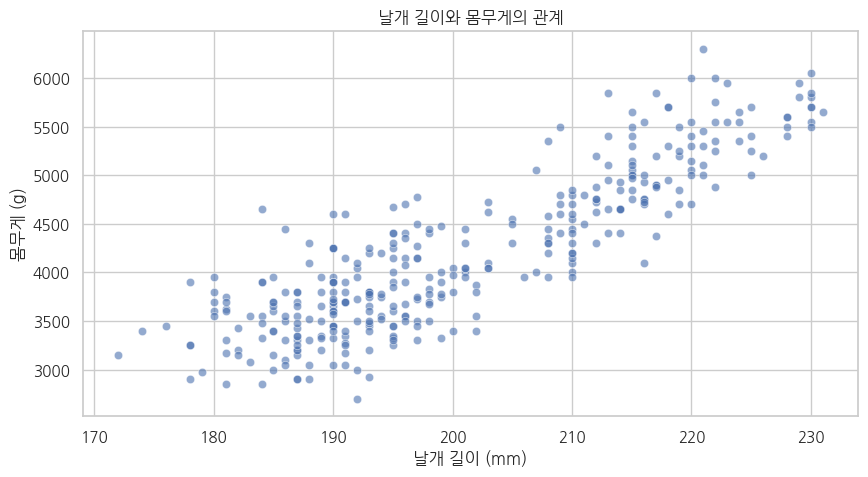

In [17]:
# 문제 2 · 데이터 준비 — 실행만 하세요
df_corr = penguins[['flipper_length_mm', 'body_mass_g']].dropna()

print("결측치 제거 전:", len(penguins), "행")
print("결측치 제거 후:", len(df_corr), "행")

# 두 변수의 관계를 그림으로 먼저 확인 (문제 1의 교훈!)
sns.scatterplot(data=df_corr, x='flipper_length_mm', y='body_mass_g', alpha=0.6)
plt.title("날개 길이와 몸무게의 관계")
plt.xlabel("날개 길이 (mm)")
plt.ylabel("몸무게 (g)")
plt.show()

In [18]:
# ─────────────────────────────────────────────
# 문제 2: Q1 · 정규성 검정 (Shapiro-Wilk)
# ─────────────────────────────────────────────

from scipy import stats

alpha = 0.05

for col in ['flipper_length_mm', 'body_mass_g']:
    stat, p_value = stats.shapiro(df_corr[col])
    reject = "기각 (정규성 X)" if p_value < alpha else "기각 못함 (정규성 O)"
    print(f"[{col}]")
    print(f"  통계량 = {stat:.4f}, p-value = {p_value:.4f}")
    print(f"  → 유의수준 {alpha} 기준: {reject}\n")

[flipper_length_mm]
  통계량 = 0.9515, p-value = 0.0000
  → 유의수준 0.05 기준: 기각 (정규성 X)

[body_mass_g]
  통계량 = 0.9592, p-value = 0.0000
  → 유의수준 0.05 기준: 기각 (정규성 X)



In [19]:
# ─────────────────────────────────────────────
# 문제 2: Q2 · 피어슨 상관계수 + p-값
# ─────────────────────────────────────────────

r, p_value = stats.pearsonr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

print(f"피어슨 상관계수 r = {r:.4f}")
print(f"p-value = {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print(f"→ 유의수준 {alpha} 기준: 귀무가설(상관계수=0) 기각 → 통계적으로 유의한 상관관계")
else:
    print(f"→ 유의수준 {alpha} 기준: 귀무가설 기각 못함 → 유의한 상관관계라고 보기 어려움")

피어슨 상관계수 r = 0.8712
p-value = 0.0000000000
→ 유의수준 0.05 기준: 귀무가설(상관계수=0) 기각 → 통계적으로 유의한 상관관계


In [21]:
# ─────────────────────────────────────────────
# 문제 2: Q3 · 스피어만 상관계수 vs 피어슨
# ─────────────────────────────────────────────

rho, p_value_spearman = stats.spearmanr(df_corr['flipper_length_mm'], df_corr['body_mass_g'])

print("피어슨 vs 스피어만 비교")
print(f"  피어슨  r   = {r:.4f}   (p-value = {p_value:.2e})")
print(f"  스피어만 ρ  = {rho:.4f}   (p-value = {p_value_spearman:.2e})")
print(f"\n  차이 (|r - ρ|) = {abs(r - rho):.4f}")

피어슨 vs 스피어만 비교
  피어슨  r   = 0.8712   (p-value = 4.37e-107)
  스피어만 ρ  = 0.8400   (p-value = 2.76e-92)

  차이 (|r - ρ|) = 0.0312


# 문제 2 · Q4

## 정규성 검정 결과 (피어슨의 전제가 지켜졌나요?):
두 변수 모두 Shapiro-Wilk 검정에서 p-value ≈ 0.0000 (< 0.05)로 나와
"정규분포를 따른다"는 귀무가설이 기각되었다.
즉 flipper_length_mm, body_mass_g 모두 엄밀한 정규분포는 아니며,
피어슨 상관계수가 이론적으로 전제하는 조건이 완전히 충족되지는 않았다.
다만 표본 수(342개)가 크기 때문에 아주 작은 편차에도 검정이 민감하게 반응했을 가능성이 있고,
산점도 상으로는 뚜렷한 이상치나 심한 비대칭이 보이지 않는다.

## 피어슨 r 값과 p-값:
r = 0.8712, p-value ≈ 0 (4.37e-107)
r = 0.8712는 두 변수 사이에 강한 선형 관계가 있다는 뜻이고,
p-value가 극도로 작다는 것은 "모집단에서 상관계수가 0이다(관계가 없다)"라는
귀무가설을 기각할 수 있다는 뜻이다. 즉 이 상관관계가 우연히 관측될 확률은
사실상 0에 가까우며, 통계적으로 매우 유의한 관계다.

## 스피어만 ρ 값:
ρ = 0.8400 (p-value = 2.76e-92)
피어슨 r(0.8712)과 차이가 0.0312에 불과할 정도로 거의 비슷하다.
이는 두 변수의 관계가 순수한 직선 형태에 가깝고, 몇 개의 이상치가
피어슨 값을 부풀리거나 왜곡시키고 있지 않다는 근거가 된다.
즉 Q1에서 정규성이 기각되긴 했지만, 그 위반이 상관관계 해석 자체를
흔들 정도로 심각하지는 않다는 것을 스피어만 값이 뒷받침해준다.

## 부호(+/-)가 뜻하는 관계의 방향:
r, ρ 모두 양수(+)다. 즉 날개 길이가 길어질수록 몸무게도 함께 증가하는
양의 관계다 — 몸집이 큰 개체일수록 날개도 길고 몸무게도 많이 나간다는,
생물학적으로 자연스러운 방향이다. 산점도에서 오른쪽 위로 올라가는
추세로도 이 방향이 그대로 확인된다.

## 절대값의 크기가 뜻하는 관계의 강도:
|r| = 0.87 안팎은 상관관계 강도 기준으로 "강한(strong)" 수준에 해당한다
(보통 0.7~0.9는 강한 상관, 0.9 이상이면 매우 강한 상관으로 본다).
즉 날개 길이만으로도 몸무게 변화의 상당 부분을 설명할 수 있을 만큼
두 변수는 밀접하게 붙어서 움직인다.

## 문제 2 정리 — 결과를 말로 설명해 보기

**① 정규성이 기각됐으니 피어슨을 쓰면 안 되는가**

"쓰면 안 되나"가 아니라 "결론이 흔들리는가"로 물어야 합니다. Q1에서 두 변수 모두 Shapiro-Wilk 검정에서 정규성이 기각됐지만, Q3에서 구한 스피어만 ρ(0.8400)와 Q2의 피어슨 r(0.8712)의 차이는 0.0312에 불과합니다. 정규성 위반이 결과를 심각하게 왜곡시켰다면 순위 기반인 스피어만과 값 기반인 피어슨이 꽤 벌어졌을 텐데, 거의 같게 나왔다는 건 **전제 위배의 실질적 영향이 미미하다**는 뜻입니다. 표본 크기가 342개로 커서 아주 작은 비대칭에도 Shapiro-Wilk가 민감하게 반응했을 뿐, 관계 자체의 형태는 선형에 가깝다고 봐도 무방합니다. 그래서 이 경우엔 피어슨 r=0.8712를 그대로 신뢰해도 됩니다.

**② 피어슨과 스피어만이 비슷하다는 것의 의미, 크게 달랐다면?**

두 값이 비슷하다는 건 다음 두 가지를 동시에 뜻합니다.
- 관계가 (곡선이 아니라) **직선에 가까운 단조 증가** 형태다
- **이상치 몇 개가 r을 부풀리거나 깎아내리고 있지 않다** — 순위로 바꾸면 이상치의 영향력이 확 줄어드는데도 값이 안 변했다는 건 애초에 이상치 문제가 없었다는 뜻

만약 두 값이 크게 달랐다면 (예: 피어슨은 낮은데 스피어만은 높다면) 관계는 있지만 비선형(곡선형)일 가능성을 의심해야 하고, (예: 피어슨만 유독 높다면) 소수의 극단적 이상치가 직선 관계를 인위적으로 만들어내고 있을 가능성을 의심해야 합니다. 이럴 땐 산점도를 다시 열어 이상치나 곡률을 눈으로 확인하는 게 먼저입니다.

**③ Q2의 p-값은 무엇에 대한 검정인가, "크다"와 "유의하다"는 같은 말인가**

Q2의 p-값은 "모집단의 상관계수가 0이다(즉 두 변수 사이에 관계가 없다)"라는 귀무가설에 대한 검정입니다. 다시 말해 **관계가 존재하느냐**를 묻는 질문이지, **관계가 얼마나 강하냐**를 묻는 질문이 아닙니다.

그래서 "상관계수가 크다"와 "유의하다"는 전혀 다른 말입니다.
- **크기(r=0.87)**: 효과의 강도 — 두 변수가 얼마나 강하게 맞물려 움직이는가
- **유의성(p≈0)**: 이 관계가 우연히 관측됐을 가능성이 거의 없다는 것

표본이 크면(여기선 342개) r=0.1 같은 아주 약한 상관도 p<0.05로 "유의하게" 나올 수 있습니다. 이번 경우엔 r 자체가 0.87로 크고 p-값도 극히 작아 두 조건이 다 만족됐지만, 일반적으로는 항상 둘을 분리해서 봐야 합니다.

**④ "날개가 길어지는 것이 몸무게를 무겁게 만드는 원인이다"라고 할 수 있는가**

상관관계 하나만으로는 인과를 주장할 수 없습니다. 세 가지 대안을 먼저 배제해야 합니다.

- **교란변수(confounder)**: 문제 1에서 만난 종(species)이 여기서도 후보입니다. Gentoo는 날개도 길고 몸무게도 많이 나가는 종이고, Adelie는 둘 다 작은 종입니다. 즉 "종"이라는 제3의 변수가 날개 길이와 몸무게 둘 다에 영향을 줘서, 실제로는 종만 다를 뿐인데 마치 날개 길이가 몸무게를 결정하는 것처럼 보일 수 있습니다. (문제 1과 달리 이번엔 종별로 나눠도 부호가 안 뒤집힐 가능성이 높지만, 그래도 확인 없이는 배제할 수 없습니다.)
- **역인과(reverse causation)**: 몸무게가 늘어난(영양 상태가 좋은) 개체가 성장하면서 날개도 함께 길어졌을 수 있습니다 — 즉 "몸무게 증가 → 날개 길이 증가" 방향일 수도 있고, 실제로는 둘 다 개체의 성장·연령·영양 상태라는 공통 원인의 결과일 가능성이 큽니다.
- **우연**: p-value가 사실상 0에 가까워서 우연으로 이 정도 상관이 나올 가능성은 거의 배제할 수 있습니다. 이 데이터 안에서는 우연이라는 설명은 설득력이 낮습니다.

종합하면, 우연은 배제할 수 있지만 교란변수와 역인과는 이 상관계수 계산만으로는 배제되지 않습니다. "관계가 있다"까지는 확실히 말할 수 있어도, "날개가 길어지는 것이 원인이다"라고 단정하려면 종을 통제한 분석이나 실험적/시계열적 설계가 추가로 필요합니다.

In [22]:
# 문제 3 · 데이터 준비 — 실행만 하세요
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

print("분석에 사용할 데이터:", len(penguins_cleaned), "행")
print("문제 2의 df_corr과 동일한가?:", len(penguins_cleaned) == len(df_corr))

INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 05:06:26] "GET /ping HTTP/1.1" 200 -


분석에 사용할 데이터: 342 행
문제 2의 df_corr과 동일한가?: True


In [25]:
# ─────────────────────────────────────────────
# 문제 3: Q1, Q2 · 단순회귀 모델 적합
# ─────────────────────────────────────────────

import statsmodels.formula.api as smf

model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):          4.37e-107
Time:                        05:10:18   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

In [26]:
# ─────────────────────────────────────────────
# 문제 3: Q3 · 회귀식 완성
# ─────────────────────────────────────────────

intercept = model.params['Intercept']
slope = model.params['flipper_length_mm']

print(f"절편(Intercept) = {intercept:.4f}")
print(f"기울기(flipper_length_mm 계수) = {slope:.4f}")
print(f"\n회귀식: body_mass_g = {intercept:.2f} + {slope:.2f} × flipper_length_mm")

절편(Intercept) = -5780.8314
기울기(flipper_length_mm 계수) = 49.6856

회귀식: body_mass_g = -5780.83 + 49.69 × flipper_length_mm


In [27]:
# ─────────────────────────────────────────────
# 문제 3: Q4 · 날개 길이 +10mm일 때 몸무게 증가량 예측
# ─────────────────────────────────────────────

slope = model.params['flipper_length_mm']
weight_diff = slope * 10

print(f"기울기 = {slope:.4f} g/mm")
print(f"날개 길이가 10mm 더 길면, 몸무게는 약 {weight_diff:.2f}g 더 무거울 것으로 예측됩니다.")

기울기 = 49.6856 g/mm
날개 길이가 10mm 더 길면, 몸무게는 약 496.86g 더 무거울 것으로 예측됩니다.


In [28]:
# ─────────────────────────────────────────────
# 문제 3: Q5 · 상관과 회귀를 잇는 두 관계식 확인
# ─────────────────────────────────────────────

# ① 기울기 = r × (y의 표준편차 / x의 표준편차)
std_x = penguins_cleaned['flipper_length_mm'].std(ddof=1)
std_y = penguins_cleaned['body_mass_g'].std(ddof=1)

slope_lhs = model.params['flipper_length_mm']           # 좌변: 실제 회귀 기울기
slope_rhs = r * (std_y / std_x)                          # 우변: r × (Sy/Sx)

print("① 기울기 = r × (y표준편차 / x표준편차)")
print(f"  좌변 (모델의 기울기)         = {slope_lhs:.6f}")
print(f"  우변 (r × std_y / std_x)    = {slope_rhs:.6f}")
print(f"  차이                        = {abs(slope_lhs - slope_rhs):.10f}")

print("\n" + "="*50 + "\n")

# ② 결정계수 R² = r²
r_squared_lhs = model.rsquared     # 좌변: 모델의 R²
r_squared_rhs = r ** 2             # 우변: 문제2 Q2의 r을 제곱

print("② R² = r²")
print(f"  좌변 (model.rsquared)  = {r_squared_lhs:.6f}")
print(f"  우변 (r ** 2)          = {r_squared_rhs:.6f}")
print(f"  차이                   = {abs(r_squared_lhs - r_squared_rhs):.10f}")

① 기울기 = r × (y표준편차 / x표준편차)
  좌변 (모델의 기울기)         = 49.685566
  우변 (r × std_y / std_x)    = 49.685566
  차이                        = 0.0000000000


② R² = r²
  좌변 (model.rsquared)  = 0.758993
  우변 (r ** 2)          = 0.758993
  차이                   = 0.0000000000


## 문제 3 정리 — 결과를 말로 설명해 보기

**① 기울기(b)를 문장으로 풀어 쓰기**

날개 길이가 1mm 길어질 때마다, 몸무게는 평균적으로 약 49.69g씩 무거워집니다. 이 관계는 통계적으로도 유의합니다(P>|t| = 0.000). 앞서 Q4에서 본 것처럼 10mm 차이면 약 496.86g, 이는 선형관계이므로 어느 구간에서든 동일하게 적용됩니다.

**② 절편(a)이 음수인데, "날개 길이 0mm인 펭귄의 몸무게"로 해석해도 되는가**

안 됩니다. 절편 -5780.83은 회귀직선을 수식으로 완성하기 위한 수학적 기준점일 뿐, 실제로 해석 가능한 값이 아닙니다. 이유는 두 가지입니다.

- 데이터에 존재하는 날개 길이 범위는 약 172~231mm입니다. 0mm는 이 범위를 한참 벗어난 **외삽(extrapolation)** 영역이라, 회귀모델이 그 지점에서도 같은 직선 관계를 유지한다고 보장할 근거가 전혀 없습니다.
- 애초에 날개 길이 0mm인 펭귄은 생물학적으로 존재할 수 없으므로, 이 숫자에 "의미"를 부여하려는 시도 자체가 무의미합니다.

회귀식은 **관측된 데이터 범위 안에서만** 예측·해석에 쓸 수 있고, 절편은 그저 직선의 y축 교점일 뿐입니다.

**③ x와 y를 바꾸면 기울기와 R²는 각각 같을까, 다를까**

여기서 갈리는 지점이 바로 Q5의 두 관계식입니다.

- **R²는 같습니다.** R² = r²인데, 상관계수 r은 x와 y를 바꿔도 값이 그대로입니다(`corr(x,y) = corr(y,x)`이므로 대칭). 따라서 어느 쪽을 설명변수로 두든 R²는 0.759로 동일합니다.
- **기울기는 다릅니다.** 기울기 = r × (표준편차 비율)인데, 이 비율(Sy/Sx)은 x와 y를 바꾸면 **역수**가 됩니다(Sx/Sy). r은 그대로라도 곱해지는 비율이 뒤집히니, "날개 길이 → 몸무게"의 기울기와 "몸무게 → 날개 길이"의 기울기는 서로 다른 값이 나오고, 심지어 단순히 역수 관계도 아닙니다(r이 1이 아닌 이상 두 기울기를 곱해도 1이 안 됨).

즉 **"관계의 강도(R², r)"는 방향과 무관한 대칭적 성질**이지만, **"기울기(변화율)"는 무엇을 원인/설명변수로 두느냐에 따라 달라지는 방향성 있는 값**입니다.

**④ 회귀가 상관보다 더 알려주는 것**

상관계수 r은 "관계가 얼마나 강한가"라는 **강도**만 알려줍니다. 단위가 없는 -1~1 스케일이라, "날개가 길수록 몸무게가 늘어나는 경향이 강하다"는 정도까지만 말할 수 있습니다.

반면 회귀의 기울기 b는 **"1mm당 몇 g"이라는 구체적인 변화량**을 알려줍니다. 이건 상관계수만으로는 절대 나올 수 없는 정보입니다. 실무 보고서에 "날개 길이가 10mm 길면 몸무게가 약 497g 더 무겁다"처럼 **실제 단위로 예측하고 설명하려면** 반드시 회귀식(기울기)이 필요하고, "두 변수가 얼마나 밀접하게 붙어 움직이는가"만 말하고 싶다면 상관계수로 충분합니다.

정리하면, 상관은 **관계의 존재와 강도**를, 회귀는 거기에 더해 **구체적인 예측식과 변화량**을 제공합니다. 이번 문제 3에서 확인한 두 관계식(①②)은 결국 이 둘이 별개가 아니라 같은 선형관계를 다른 방식으로 표현한 것임을 수치로 보여준 것입니다.

## 문제 4 풀이 — Q1

```
# 문제 4 · Q1

## H₀ (귀무가설):
모집단에서 날개 길이(flipper_length_mm)의 회귀계수(기울기) β = 0이다.
즉 날개 길이는 몸무게를 설명하는 데 아무런 선형 관계가 없다
(날개 길이가 변해도 몸무게는 평균적으로 변하지 않는다).

## H₁ (대립가설):
모집단에서 날개 길이의 회귀계수(기울기) β ≠ 0이다.
즉 날개 길이와 몸무게 사이에는 (0이 아닌) 선형 관계가 존재한다
(날개 길이가 변하면 몸무게도 평균적으로 함께 변한다).
```

### 해석 메모

- 여기서 검정 대상은 **모집단의 참 기울기 β**이지, 우리가 표본에서 추정한 값(49.6856)이 아닙니다. 표본 기울기는 이미 계산된 하나의 관측값이고, 가설검정은 "이 관측값이 우연히 β=0인 모집단에서 나왔다고 보기 어려운가"를 판단하는 과정입니다.
- 문제 3 Q2의 결과표에서 `flipper_length_mm` 행의 **P>|t| = 0.000**이 바로 이 H₀에 대한 검정 결과입니다. p-value가 극히 작으므로 H₀(β=0)을 기각하고, H₁(β≠0)을 채택합니다 — 즉 날개 길이와 몸무게 사이의 선형 관계가 통계적으로 유의합니다.
- 참고로 이 검정은 **양측검정**(≠)으로 세웠습니다. "날개가 길수록 몸무게가 늘어난다"는 방향까지 사전에 가정하고 싶다면 H₁을 β > 0으로 하는 단측검정도 가능하지만, 통상적인 회귀분석 결과표(`P>|t|`)는 양측검정 기준으로 계산됩니다.

In [29]:
# ─────────────────────────────────────────────
# 문제 4: Q2 · 기울기(flipper_length_mm)의 p-value
# ─────────────────────────────────────────────

p_slope = model.pvalues['flipper_length_mm']

print(f"flipper_length_mm 의 P>|t| = {p_slope}")
print(f"소수점으로 표기: {p_slope:.10f}")

flipper_length_mm 의 P>|t| = 4.370680963000337e-107
소수점으로 표기: 0.0000000000


In [30]:
# ─────────────────────────────────────────────
# 문제 4: Q3 · 유의수준 0.05로 결론 내리기
# ─────────────────────────────────────────────

alpha = 0.05
p_slope = model.pvalues['flipper_length_mm']

if p_slope < alpha:
    conclusion = f"p-value({p_slope:.4e})가 유의수준 {alpha}보다 작으므로, 귀무가설(H₀: β=0)을 기각한다."
    conclusion += "\n→ 날개 길이와 몸무게 사이에는 통계적으로 유의한 선형 관계가 있다고 결론 내린다."
else:
    conclusion = f"p-value({p_slope:.4e})가 유의수준 {alpha}보다 크므로, 귀무가설(H₀: β=0)을 기각하지 못한다."
    conclusion += "\n→ 날개 길이와 몸무게 사이에 선형 관계가 있다고 볼 통계적 근거가 부족하다."

print(conclusion)

p-value(4.3707e-107)가 유의수준 0.05보다 작으므로, 귀무가설(H₀: β=0)을 기각한다.
→ 날개 길이와 몸무게 사이에는 통계적으로 유의한 선형 관계가 있다고 결론 내린다.


In [31]:
# ─────────────────────────────────────────────
# 문제 4: Q4 · 상관계수 검정 t값 vs 회귀계수 검정 t값
# ─────────────────────────────────────────────

n = len(penguins_cleaned)

t_manual = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
t_model = model.tvalues['flipper_length_mm']

print(f"n = {n}, r = {r:.4f}")
print(f"공식으로 직접 계산한 t   = {t_manual:.6f}")
print(f"model.tvalues에서 가져온 t = {t_model:.6f}")
print(f"차이                     = {abs(t_manual - t_model):.10f}")

n = 342, r = 0.8712
공식으로 직접 계산한 t   = 32.722234
model.tvalues에서 가져온 t = 32.722234
차이                     = 0.0000000000


In [32]:
# ─────────────────────────────────────────────
# 문제 4: Q5 · Adelie 수컷 - bill_length_mm → body_mass_g
# ─────────────────────────────────────────────

# 필요한 열의 결측치 먼저 제거
penguins_sub = penguins.dropna(subset=['bill_length_mm', 'body_mass_g', 'sex'])

# Adelie 종, 수컷만 필터링
adelie_male = penguins_sub[(penguins_sub['species'] == 'Adelie') & (penguins_sub['sex'] == 'Male')]

model_sub = smf.ols(formula='body_mass_g ~ bill_length_mm', data=adelie_male).fit()

n_sub = len(adelie_male)
p_sub = model_sub.pvalues['bill_length_mm']
r_squared_sub = model_sub.rsquared
alpha = 0.05

print(f"표본 크기 n = {n_sub}")
print(f"기울기 = {model_sub.params['bill_length_mm']:.4f}")
print(f"기울기의 p-value = {p_sub:.4f}")
print(f"R² = {r_squared_sub:.4f}")

print()
if p_sub < alpha:
    print(f"→ p-value({p_sub:.4f}) < {alpha} 이므로 귀무가설(β=0)을 기각한다.")
    print("  bill_length_mm과 body_mass_g 사이에 유의한 선형 관계가 있다.")
else:
    print(f"→ p-value({p_sub:.4f}) ≥ {alpha} 이므로 귀무가설(β=0)을 기각하지 못한다.")
    print("  이 표본에서는 bill_length_mm과 body_mass_g 사이에 유의한 선형 관계가 있다고 보기 어렵다.")

표본 크기 n = 73
기울기 = 33.5628
기울기의 p-value = 0.0610
R² = 0.0486

→ p-value(0.0610) ≥ 0.05 이므로 귀무가설(β=0)을 기각하지 못한다.
  이 표본에서는 bill_length_mm과 body_mass_g 사이에 유의한 선형 관계가 있다고 보기 어렵다.


## 문제 4 정리 — 결과를 말로 설명해 보기

**① p-값이 작다는 것은 정확히 무엇이 작다는 뜻인가, "귀무가설이 참일 확률"이라 해도 되는가**

안 됩니다. p-value는 **"귀무가설(H₀: β=0)이 참이라고 가정했을 때, 지금 관측된 것만큼(혹은 더 극단적인) 결과가 나올 확률**"입니다. 즉 조건부 확률이고, 조건과 결론이 반대로 뒤집혀 있습니다.

- 맞는 말: "H₀가 참이라면, 이런 데이터가 나올 확률은 작다"
- 틀린 말: "H₀가 참일 확률은 작다"

이 둘은 완전히 다른 명제입니다. p-value는 애초에 "H₀가 참일 확률"을 계산하지 않습니다 — 그건 베이지안적 질문이고, 지금 우리가 쓰는 빈도주의 검정은 H₀를 고정해놓고 데이터의 극단성만 따집니다. p-value가 작다는 건 "H₀ 하에서는 이 데이터가 매우 이례적이다"라는 뜻이지, "H₀가 틀렸을 확률"이 아닙니다.

**② Q4에서 두 t값이 일치한 것은 무엇을 뜻하는가**

단순회귀(설명변수 1개)에서 "회귀계수 β=0"을 검정하는 것과 "상관계수 ρ=0"을 검정하는 것은 **같은 가설을 두 가지 언어로 적은 것**일 뿐입니다. 문제 3 Q5에서 확인했듯 β = r × (Sy/Sx)이므로, β와 r은 스케일만 다를 뿐 0이 되는 조건이 정확히 같습니다(r=0이면 β=0, 그 역도 성립). 그래서 두 검정의 t-통계량도, p-value도 완전히 같은 숫자가 나올 수밖에 없습니다. 상관분석과 단순회귀분석이 겉모습은 달라도 **본질적으로 하나의 검정**이라는 걸 숫자로 확인한 셈입니다.

**③ Q5의 결과는 Q2와 어떻게 달랐나 — 표본 크기와 R² 두 측면에서**

| | Q2 (전체, 날개길이-몸무게) | Q5 (Adelie 수컷만, 부리길이-몸무게) |
|---|---|---|
| n | 342 | 73 |
| R² | 0.759 | 0.0486 |
| p-value | ≈ 0 | 0.0610 |
| 결론 | H₀ 기각 | H₀ 기각 못함 |

두 가지 요인이 동시에 작용했습니다.

- **표본 크기**: n이 342에서 73으로 줄면서, 통계적 검정력(power)이 크게 떨어졌습니다. t = r√(n-2)/√(1-r²) 공식을 보면 n이 작아질수록 t값 자체가 작아지는 구조라, 같은 강도의 관계라도 표본이 작으면 유의성을 확보하기 어려워집니다.
- **관계의 강도**: R²가 0.759에서 0.0486으로 급락했습니다. 이건 표본 크기 문제와는 별개로, **종과 성별을 하나로 고정하고 나니 부리 길이와 몸무게 사이의 실제 선형 관계 자체가 원래 약했다**는 뜻입니다. 문제 1에서 본 것과 비슷한 구조로, 전체 데이터에서 보이던 강한 관계의 상당 부분이 종/성별이라는 그룹 차이에서 왔을 가능성이 있고, 그 그룹을 없애고 나니 부리 길이만으로는 몸무게를 설명하는 힘이 거의 남지 않은 것입니다.

즉 이번엔 "표본이 작아서 못 봤다"기보다는 **"관계 자체가 원래 약했다(R²=0.0486)"는 쪽에 무게가 더 실립니다.** 표본이 작은 게 겹쳐서 유의성 확보가 더 어려워지긴 했지만, R²가 이렇게 낮으면 n을 늘려도 유의해질지언정 실질적으로 의미 있는 관계라고 보긴 어렵습니다.

**④ p-값이 0.05보다 조금 큰 경우, "관계가 없음이 증명되었다"고 할 수 있는가**

아닙니다. 이건 통계적 검정에서 가장 흔히 저지르는 오해 중 하나입니다.

- **틀린 말**: "관계가 없다는 것이 증명되었다"
- **정확한 말**: "이 표본(n=73)으로는 관계가 있다는 통계적 증거를 충분히 확보하지 못했다"

가설검정은 애초에 "H₀가 참이다"를 증명하는 도구가 아닙니다. 오직 "H₀를 기각할 근거가 있는가"만 판단할 수 있고, 기각하지 못했다는 건 "무죄"가 아니라 "유죄를 입증하기엔 증거 부족"에 가깝습니다. 특히 이번 경우처럼 p-value(0.0610)가 0.05를 아주 근소하게 넘긴 상황에서는 더더욱 조심해야 합니다 — 표본이 조금만 더 컸어도(n이 늘었어도) 유의해졌을 가능성을 배제할 수 없기 때문입니다.

그래서 정확한 서술은: "Adelie 종 수컷 표본(n=73)에서는 부리 길이가 몸무게를 유의하게 설명한다고 볼 통계적 근거가 부족했다(p=0.061). 다만 R²도 0.0486으로 낮아, 표본을 늘린다 해도 실질적으로 강한 관계가 드러날 가능성은 크지 않아 보인다." — 이렇게 **"증거 부족"과 "관계의 강도"를 분리해서** 말하는 것이 통계적으로 정직한 결론입니다.

In [33]:
# 문제 5 · 데이터 준비 — 실행만 하세요
# 문제 3의 Q1을 먼저 완료해야 이 문제를 풀 수 있습니다.

print("분석 대상 데이터:", len(penguins_cleaned), "행")
print("모형: body_mass_g ~ flipper_length_mm")

분석 대상 데이터: 342 행
모형: body_mass_g ~ flipper_length_mm


In [34]:
# ─────────────────────────────────────────────
# 문제 5: Q1 · 결정계수(R²)로 설명력 평가
# ─────────────────────────────────────────────

r_squared = model.rsquared

print(f"R-squared = {r_squared:.4f}")
print(f"→ 몸무게(body_mass_g) 변동의 약 {r_squared*100:.1f}%를 flipper_length_mm 하나로 설명한다.")

R-squared = 0.7590
→ 몸무게(body_mass_g) 변동의 약 75.9%를 flipper_length_mm 하나로 설명한다.


In [35]:
# ─────────────────────────────────────────────
# 문제 5: Q2 · 예측값과 잔차 계산
# ─────────────────────────────────────────────

fitted = model.fittedvalues   # 예측값
resid = model.resid           # 잔차 (실제값 - 예측값)

print(f"잔차 개수 = {len(resid)}")
print(f"잔차 평균 = {resid.mean():.10f}")

잔차 개수 = 342
잔차 평균 = 0.0000000000


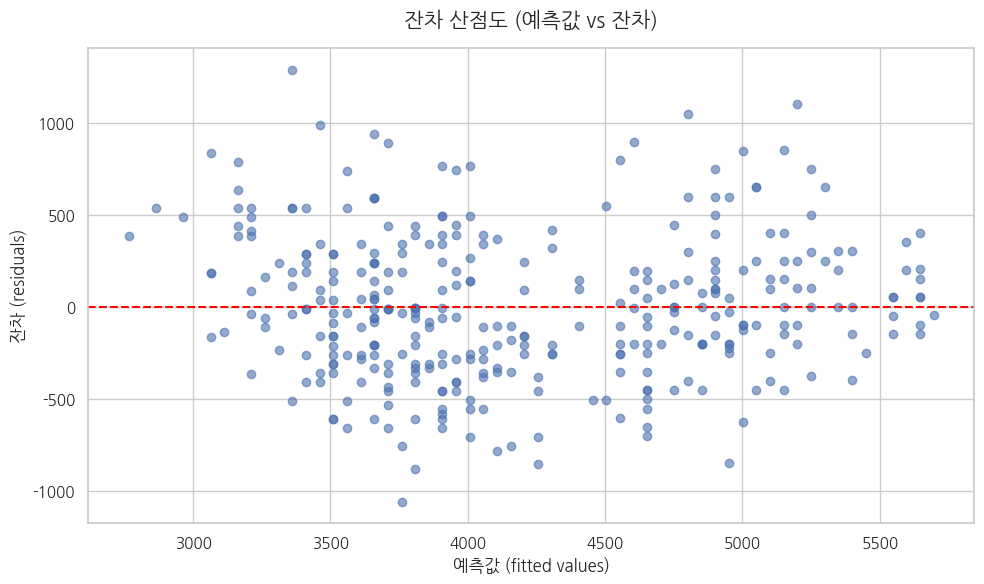

In [36]:
# ─────────────────────────────────────────────
# 문제 5: Q3 · 잔차 산점도 (예측값 vs 잔차)
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 6))

plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.title('잔차 산점도 (예측값 vs 잔차)', fontsize=15, pad=15)
plt.xlabel('예측값 (fitted values)', fontsize=12)
plt.ylabel('잔차 (residuals)', fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
# ─────────────────────────────────────────────
# 문제 5: Q4 · 브루쉬-페이건 검정 (등분산성)
# ─────────────────────────────────────────────

from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(model.resid, model.model.exog)

alpha = 0.05

print(f"LM 통계량 = {lm_stat:.4f}, LM p-value = {lm_pvalue:.4f}")
print(f"F 통계량   = {f_stat:.4f}, F p-value   = {f_pvalue:.4f}")
print()

if lm_pvalue < alpha:
    print(f"→ p-value({lm_pvalue:.4f}) < {alpha} 이므로 귀무가설(등분산이다)을 기각한다.")
    print("  잔차의 분산이 예측값 수준에 따라 달라지는 이분산성이 의심된다.")
else:
    print(f"→ p-value({lm_pvalue:.4f}) ≥ {alpha} 이므로 귀무가설(등분산이다)을 기각하지 못한다.")
    print("  등분산성 가정을 위반한다고 볼 통계적 근거가 부족하다.")

LM 통계량 = 2.1579, LM p-value = 0.1418
F 통계량   = 2.1589, F p-value   = 0.1427

→ p-value(0.1418) ≥ 0.05 이므로 귀무가설(등분산이다)을 기각하지 못한다.
  등분산성 가정을 위반한다고 볼 통계적 근거가 부족하다.


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     186.4
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           3.81e-34
Time:                        05:39:48   Log-Likelihood:                -2697.0
No. Observations:                 342   AIC:                             5398.
Df Residuals:                     340   BIC:                             5406.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        362.3067    283.345      1.

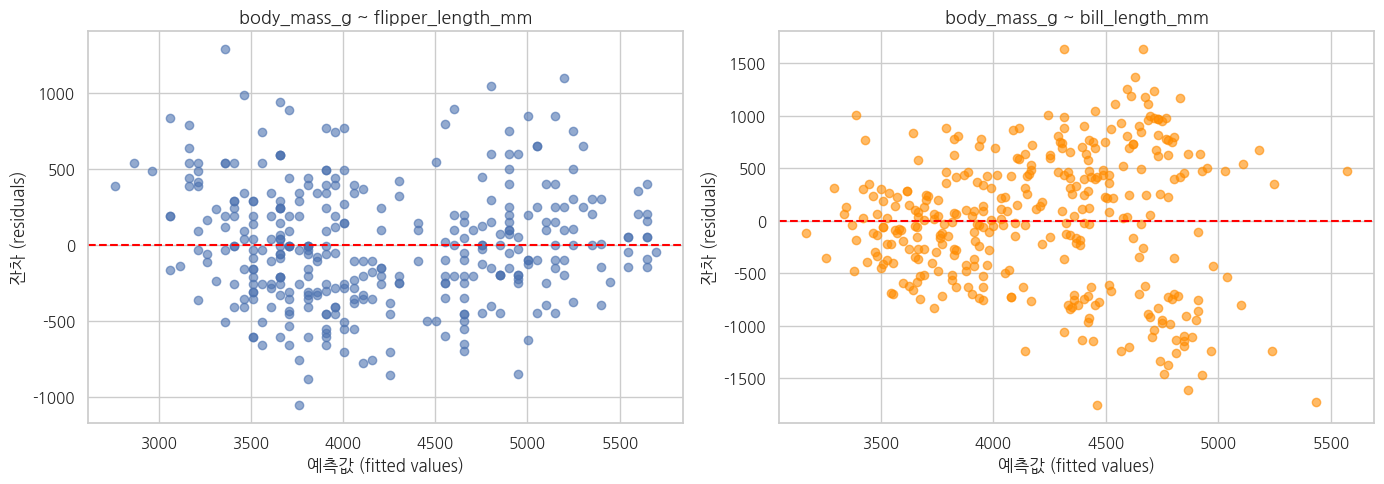

In [38]:
# ─────────────────────────────────────────────
# 문제 5: Q5 · 비교 모형(model_bill)과 나란히 비교
# ─────────────────────────────────────────────

from statsmodels.stats.diagnostic import het_breuschpagan

# 1) bill_length_mm, body_mass_g 결측치 제거한 데이터로 비교 모형 적합
penguins_bill = penguins.dropna(subset=['bill_length_mm', 'body_mass_g'])
model_bill = smf.ols(formula='body_mass_g ~ bill_length_mm', data=penguins_bill).fit()

print(model_bill.summary())
print("\n" + "="*60 + "\n")

# 2) 두 모형의 잔차 산점도 나란히 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: flipper_length_mm 모형
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('body_mass_g ~ flipper_length_mm', fontsize=13)
axes[0].set_xlabel('예측값 (fitted values)')
axes[0].set_ylabel('잔차 (residuals)')

# 오른쪽: bill_length_mm 모형
axes[1].scatter(model_bill.fittedvalues, model_bill.resid, alpha=0.6, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('body_mass_g ~ bill_length_mm', fontsize=13)
axes[1].set_xlabel('예측값 (fitted values)')
axes[1].set_ylabel('잔차 (residuals)')

plt.tight_layout()
plt.show()

# 3) 두 모형의 브루쉬-페이건 p-값 비교
lm_stat_bill, lm_pvalue_bill, f_stat_bill, f_pvalue_bill = het_breuschpagan(
    model_bill.resid, model_bill.model.exog
)

alpha = 0.05

print("모형별 브루쉬-페이건 검정 비교")
print(f"  [flipper_length_mm 모형]  LM p-value = {lm_pvalue:.4f}   (R² = {model.rsquared:.4f})")
print(f"  [bill_length_mm 모형]     LM p-value = {lm_pvalue_bill:.4f}   (R² = {model_bill.rsquared:.4f})")

print()
if lm_pvalue_bill < alpha:
    print(f"→ bill_length_mm 모형: p-value({lm_pvalue_bill:.4f}) < {alpha} → 귀무가설(등분산) 기각")
    print("  이 모형은 이분산성이 의심된다.")
else:
    print(f"→ bill_length_mm 모형: p-value({lm_pvalue_bill:.4f}) ≥ {alpha} → 귀무가설(등분산) 기각 못함")
    print("  이 모형도 등분산성 위반 근거는 부족하다.")

## 문제 5 풀이 — Q6

```
# 문제 5 · Q6 · 보고 문장

날개 길이(flipper_length_mm)로 몸무게(body_mass_g)를 예측하는 단순회귀모형에서,
날개 길이가 1mm 증가할 때마다 몸무게는 평균적으로 49.69g 증가했으며
(β=49.69, p<.001), 이 모형은 몸무게 변동의 75.9%를 설명했고(R²=0.759),
브루쉬-페이건 검정 결과 등분산성 가정을 위반한다는 통계적 근거는
발견되지 않았다(p=0.142).
```

### 문장을 뜯어보면

| 담아야 할 요소 | 실제 반영 부분 |
|---|---|
| **기울기(효과 크기)** | "1mm 증가할 때마다 49.69g 증가" — 단위가 있는 구체적 변화량 |
| **유의성** | "p<.001" — 이 기울기가 우연히 0이 아닌 값으로 관측될 확률이 매우 낮음 |
| **설명력** | "R²=0.759" — 몸무게 변동의 75.9%를 이 모형 하나로 설명 |
| **진단 결과** | "등분산성 위반 근거 없음(p=0.142)" — 회귀의 표준오차·유의성 검정을 그대로 신뢰해도 된다는 신호 |

### 비교 모형과 함께 쓰면 더 힘이 실리는 이유

이 문장이 신뢰를 얻는 건, 단순히 "우리 모형은 좋다"는 자기주장이 아니라 **비교군(bill_length_mm 모형)과 대조했을 때 상대적으로 우수하다**는 게 Q5에서 확인됐기 때문입니다.

- bill_length_mm 모형은 R²=0.354로 설명력이 훨씬 낮고, 브루쉬-페이건 p-value가 0.0000으로 이분산성까지 의심되는 상태입니다.
- 반면 flipper_length_mm 모형은 R²가 두 배 이상 높고, 등분산성 가정도 지켜지고 있습니다.

그래서 보고서에 이 문장 뒤에 한 줄을 덧붙인다면:

> "이는 bill_length_mm을 설명변수로 쓴 모형(R²=0.354, 이분산성 의심 p<.001)보다 설명력과 모형 적합도 측면에서 더 안정적인 결과다."

라고 이어 붙이면, 왜 하필 flipper_length_mm을 최종 모형으로 선택했는지에 대한 근거까지 한 번에 정리됩니다.

## 문제 5 정리 — 결과를 말로 설명해 보기

**① Q3·Q4에서 우리 모형(flipper_length_mm)의 잔차는 어떤 상태였나, 문제 3·4의 해석을 신뢰할 수 있는가**

Q3의 잔차 산점도는 예측값이 커지든 작아지든 점들이 0을 중심으로 비교적 고르게 흩어져 있었고, 뚜렷한 나팔꼴이나 곡선 패턴이 보이지 않았습니다. Q4의 브루쉬-페이건 검정도 이를 뒷받침합니다 — p-value=0.1418로 등분산성이라는 귀무가설을 기각하지 못했습니다. 즉 잔차의 분산이 예측값 수준에 따라 체계적으로 달라진다고 볼 근거가 없습니다.

그래서 문제 3·4에서 계산한 표준오차, t값, p-value, 신뢰구간은 모두 **등분산 가정이 유효한 상태에서 계산된 값**이고, 그대로 신뢰해도 됩니다. "날개 길이 계수가 유의하다(p<.001)"는 결론과 그 기울기(49.69g/mm)의 해석 모두 안심하고 써도 되는 상태입니다.

**② Q5의 두 잔차 산점도는 어떻게 달랐나, 비교군의 모양을 뭐라 부르는가**

flipper_length_mm 모형은 예측값 전 구간에서 잔차의 세로 폭이 비슷했던 반면, bill_length_mm 모형은 예측값이 커질수록(대략 4000 이상) 잔차가 위아래로 훨씬 넓게 퍼지는 모습을 보였습니다. 예측값이 작을 땐 잔차가 촘촘하다가 커질수록 벌어지는 이 모양을, 강의에서 배운 용어로 **부채꼴(나팔꼴) 패턴 — 이분산성(heteroscedasticity)**이라고 부릅니다. 브루쉬-페이건 p-value가 0.0000으로 나온 것도 이 시각적 패턴과 정확히 일치합니다.

**③ 등분산성이 깨졌을 때, 잘못된 것은 기울기 값 자체인가 그 통계적 해석인가**

**기울기 값 자체가 아니라, 그 값의 통계적 해석(유의성·신뢰구간)이 잘못될 위험이 있는 것**입니다. OLS의 기울기 추정치(87.42) 자체는 등분산성이 깨져도 여전히 비편향 추정량이라, "point estimate로서의 기울기"는 유효합니다. 문제가 되는 건 표준오차 계산이 등분산을 전제로 만들어진 공식이라서, 이분산 상황에서는 표준오차·t값·p-value·신뢰구간이 실제보다 과소 또는 과대평가될 수 있다는 점입니다. 즉 "87.42g/mm 늘어난다"는 추정 자체는 믿을 수 있지만, "이게 통계적으로 유의하다(p<.001)"는 판단은 이분산성 때문에 왜곡됐을 가능성이 있어 그대로 신뢰하기 어렵습니다.

**④ R²가 1이 아니다 — penguins 안에서 몸무게에 영향을 줄 만한데 놓친 변수는?**

문제 1에서 이미 만난 **종(species)**이 가장 유력한 후보입니다. Gentoo는 날개도 길고 부리도 길면서 몸무게도 많이 나가는 반면, Adelie는 전반적으로 체구가 작습니다. 즉 종이 날개 길이·부리 길이·몸무게 모두에 동시에 영향을 미치는 변수인데, 지금 모델은 이걸 완전히 무시하고 있습니다. 이 외에도 **성별(sex)**과 **섬(island)** 같은 변수도 몸무게 차이에 관여할 가능성이 있습니다(예: 문제 4 Q5에서 Adelie 수컷만 따로 봤을 때 관계가 확 약해진 것도 종과 성별을 통제하지 않은 전체 모형이 놓치고 있던 부분을 보여준 사례입니다).

**⑤ 그 변수들을 모델에 함께 넣으려면 어떤 분석이 필요한가**

설명변수를 하나 더 넣어서 **여러 개의 설명변수로 하나의 반응변수를 동시에 설명하는 분석**, 즉 **다중회귀분석(multiple regression)**이 필요합니다. `body_mass_g ~ flipper_length_mm + species` 처럼 범주형 변수(species, sex)를 더미변수로 변환해 함께 넣으면, 종/성별이라는 교란변수를 통제한 상태에서 날개 길이의 순수한 효과가 얼마나 되는지 분리해서 볼 수 있습니다. 이게 다음 장(8장)에서 다룰 내용으로 보입니다.